# One-vs-all CatBoost classifiers per class on raw text, with stratified k-fold evaluation

# Import and Installing Library

In [ ]:
DATA_DIR = "../data"

In [1]:
!pip install -q CatBoost
!pip install -q datasets

In [2]:
import pandas as pd
import numpy as np
import re
from tqdm import tqdm

from transformers import (
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification,
    EarlyStoppingCallback
)

import tensorflow as tf
from catboost import CatBoostClassifier, Pool

from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, \
    balanced_accuracy_score
from datasets import Dataset, DatasetDict

In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Loading and Cleaning Data

In [5]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv", sep=";")
# ft_embed = pd.read_pickle(f'{DATA_DIR}/ft_embed.pkl')
# test_df = pd.read_csv(f'{DATA_DIR}/test.csv', sep=";")
train_df.head()

                                                text             label
0  Kunjungan Prabowo ini untuk meresmikan dan men...  Sumber Daya Alam
1  RT Anies dapat tepuk tangan meriah saat jadi R...           Politik
2  @CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...         Demografi
3  RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...           Politik
4  Anies Baswedan Harap ASN termasuk TNI dan Polr...           Politik

In [ ]:
# train_df['ft_embed'] = ft_embed['ft_embed']

In [6]:
import re
def preprocess_hashtag(hashtag):
    hashtag = hashtag.replace("M3nang", "Menang").replace("L3bih", "Lebih")
    hashtag = re.sub(r'(?i)g4njar', 'Ganjar', hashtag)
    hashtag = hashtag.lstrip('#')  # Remove the '#' symbol
    words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+', hashtag)
    return ' '.join(words).lower()  # Convert to lowercase and join with spaces

def replace_hashtags(text):
    # Find all hashtags in the text
    hashtags = re.findall(r'#\w+', text)

    # Process each hashtag and replace it in the text
    for hashtag in hashtags:
        processed = preprocess_hashtag(hashtag)
        text = text.replace(hashtag, processed)

    return text

In [7]:
def remove_noise(text):
    text = str(text)
    # remove mentions
    text = re.sub(r'@[\S+]+', '', text)
    # remove hashtags
    # text = re.sub(r'#\w+', '', text)
    # remove RT
    text = re.sub(r'RT[\s]+', '', text)
    # remove [RE ...]
    text = re.sub(r'\[RE\s+(\w+)\]', r'\1', text)
    # remove urls
    text = re.sub(r'https?:\/\/\S+', '', text)
    # remove emojis
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # fix &amp;
    text = re.sub(r'&amp;', 'dan', text)
    # fix w/
    text = re.sub(r'w/', 'with', text)
    # fix 3
    text = re.sub(r'(?<=\w)3(?=\w)', 'e', text)
    # remove any non alphanumeric characters
    text = re.sub(r'[^A-Za-z0-9 ]', ' ', text)
    # fix unspaced words
    new_text = []
    for word in text.split():
        # weird word
        if word in ["BEiqnH5xQr", "JN18A"]:
            continue
        # fix shorten names
        elif word == "JK":
            new_text.append("jusuf kalla")
        elif word.lower() == "jkw":
            new_text.append("jokowi")
        elif word.lower() in ["bowo", "ayahbowo"]:
            new_text.append("prabowo")
        elif word.lower() in ["ayahbowogbran", "pbowogbran", "masbowogbran"]:
            new_text.append("pabrowo gibran")
        elif word == "MasGBRAN":
            new_text.append("gibran")
        elif word == "SBY":
            new_text.append("susilo bambang yudhoyono")
        elif word == "AHY":
            new_text.append("agnes haryani")
        # keep as is
        elif re.fullmatch(r'[A-Z]+', word) or word.lower() in ["s1", "s2", "s3"]:
            new_text.append(word)
        else:
            # fix unspaced words
            new_text.append(re.sub(r'(?<=[a-z])(?=[A-Z])|(?<=[A-Za-z])(?=[0-9])|(?<=[0-9])(?=[A-Za-z])|(?<=[A-Z])(?=[A-Z][a-z])', ' ', word))
    text = ' '.join(new_text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    # remove whitespace leading & trailing
    text = text.strip()
    return text

def normalize_word(text):
    map = {
        "sj": "saja",
        "yg": "yang",
        "dgn": "dengan",
        "dg": "dengan",
        "dpt": "dapat",
        "dptkan": "dapatkan",
        "hnya": "hanya",
        "skrng": "sekarang",
        "uu": "undang undang",
        "asn": "aparatur sipil negara",
        "ordal": "orang dalam",
        "mrk": "mereka",
        "rmh": "rumah",
        "kpk": "komisi pemberantasan korupsi",
        "blg": "bilang",
        "tuch": "tuh",
        "umkm": "usaha mikro kecil menengah",
        "jis": "jakarta international stadium",
        "jkt": "jakarta",
        "spt": "seperti",
        "tps": "tempat pemungutan suara",
        "alkes": "alat kesehatan",
        "bowo": "prabowo",
        "maap": "maaf",
        "ga" : "tidak",
        "nggak" : "tidak"
    }

    text = text.replace("UU ITE", "Undang Undang Informasi dan Transaksi Elektronik")
    text = text.replace("kitamasbowo dangbran", "kita pilih prabowo dan gibran")
    text = text.replace("PDI P", "PDIP")
    text = text.replace("PDI Perjuangan", "PDIP")

    party_names = [
        "pkb",
        "gerindra",
        "pdi",
        "pdip",
        "golkar",
        "nasdem",
        "gelora",
        "pks",
        "pkn",
        "hanura",
        "pan",
        "pbb",
        "demokrat",
        "psi",
        "perindo",
        "ppp",
        "ummat",
        "pna",
        "gabthat",
        "pda",
        "sira"
    ]

    stop_words = [
        "dekade08",
        "tempodotco",
        "md"
    ]

    new_text = []
    for word in text.split():
        if word.lower() in map:
            new_text.append(map[word.lower()])
        elif word.lower() in party_names:
            new_text.append("Partai Politik")
        elif word.lower() in stop_words:
            continue
        else:
            new_text.append(word)

    text = ' '.join(new_text)
    return text.lower()

def drop_duplicated(df):
    print("Df size:", df.shape)
    df.drop(df[df['text'].str.len() == 0].index, inplace=True)
    print("After dropping empty text rows, df size: ", df.shape)
    df.drop_duplicates(subset=['text', 'label'], keep='first', inplace=True)
    print("After dropping literal duplicated rows, df size: ", df.shape)
    df.drop_duplicates(subset=['text'], keep=False, inplace=True)
    print("After dropping text duplicated rows, df size: ", df.shape)
    return df

In [8]:
# train_df['text'] = train_df['text'].apply(replace_hashtags)
train_df['text'] = train_df['text'].apply(remove_noise)
train_df['text'] = train_df['text'].apply(normalize_word)
train_df = drop_duplicated(train_df)
train_df.head()

Df size: (5000, 2)
After dropping empty text rows, df size:  (4991, 2)
After dropping literal duplicated rows, df size:  (4352, 2)
After dropping text duplicated rows, df size:  (4239, 2)


                                                text             label
0  kunjungan prabowo ini untuk meresmikan dan men...  Sumber Daya Alam
1  anies dapat tepuk tangan meriah saat jadi rekt...           Politik
2  emng bener sih pendukung 01 ada yang goblok be...         Demografi
3  sewaktu anies bersikap kritis ke kinerja pak p...           Politik
4  anies baswedan harap aparatur sipil negara ter...           Politik

In [ ]:
train_df.to_csv(f"{DATA_DIR}/train_cleaned_v2.csv", index=False)

In [9]:
train_df.label.value_counts()

label
Politik                    2868
Sosial Budaya               384
Ekonomi                     266
Pertahanan dan Keamanan     259
Ideologi                    255
Sumber Daya Alam            133
Demografi                    55
Geografi                     19
Name: count, dtype: int64

In [10]:
test_df['Text'] = test_df['Text'].apply(remove_noise)
test_df['Text'] = test_df['Text'].apply(normalize_word)
test_df.head()

NameError: name 'test_df' is not defined

In [ ]:
train_df[train_df['text'].isin(test_df['Text'])].drop_duplicates(subset=['text'])

,text,label
64,Anies itu prestasinya di Jakarta banyak sekali...,Politik
68,Isu Palestina tidak penting bagi Prabowo tidak...,Politik
87,Palestina di tindas karena gk punya kekuatan m...,Pertahanan dan Keamanan
160,Partai Politik Tanggapi Jokowi Prabowo Makan M...,Politik
270,nahh itu dia laeku ga bisa dibuka semua data i...,Politik
...,...,...
4869,Jadi ikut sedih juga Pak Prabowo memang sering...,Politik
4881,saat ini warga kampung bayam seharusnya bisa h...,Politik
4946,Percayalah orang pertama yang bakal didepak Pr...,Politik
4953,Anies kehilangan Otoritas bicara etika pada de...,Politik


# Feature Engineering

## Keyword Feature

In [11]:
kw_df = pd.read_excel(f"{DATA_DIR}/keywords_prob.xlsx")
kw_df.head()

                   keyword  Demografi  Ekonomi  Geografi  Ideologi  \
0        pendidikan rendah        1.0      0.0       0.0       0.0   
1           kelompok etnis        1.0      0.0       0.0       0.0   
2  masyarakat lintas etnis        1.0      0.0       0.0       0.0   
3             kaum difabel        1.0      0.0       0.0       0.0   
4                    bugis        1.0      0.0       0.0       0.0   

   Pertahanan dan Keamanan  Sosial Budaya  Sumber Daya Alam  Politik  
0                      0.0            0.0               0.0      0.0  
1                      0.0            0.0               0.0      0.0  
2                      0.0            0.0               0.0      0.0  
3                      0.0            0.0               0.0      0.0  
4                      0.0            0.0               0.0      0.0  

In [12]:
train_kw_df = train_df.copy()
train_kw_df.head()

                                                text             label
0  kunjungan prabowo ini untuk meresmikan dan men...  Sumber Daya Alam
1  anies dapat tepuk tangan meriah saat jadi rekt...           Politik
2  emng bener sih pendukung 01 ada yang goblok be...         Demografi
3  sewaktu anies bersikap kritis ke kinerja pak p...           Politik
4  anies baswedan harap aparatur sipil negara ter...           Politik

In [13]:
for kw in kw_df['keyword']:
    train_kw_df[kw] = train_kw_df['text'].str.lower().str.contains(kw).astype(int)

train_kw_df.head()

<ipython-input-13-1e0113f6a834>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df2[kw] = train_df2['text'].str.lower().str.contains(kw).astype(int)
<ipython-input-13-1e0113f6a834>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df2[kw] = train_df2['text'].str.lower().str.contains(kw).astype(int)
<ipython-input-13-1e0113f6a834>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usi

                                                text             label  \
0  kunjungan prabowo ini untuk meresmikan dan men...  Sumber Daya Alam   
1  anies dapat tepuk tangan meriah saat jadi rekt...           Politik   
2  emng bener sih pendukung 01 ada yang goblok be...         Demografi   
3  sewaktu anies bersikap kritis ke kinerja pak p...           Politik   
4  anies baswedan harap aparatur sipil negara ter...           Politik   

   pendidikan rendah  kelompok etnis  masyarakat lintas etnis  kaum difabel  \
0                  0               0                        0             0   
1                  0               0                        0             0   
2                  1               0                        0             0   
3                  0               0                        0             0   
4                  0               0                        0             0   

   bugis  generasi emas  low educated  menengah bawah  ...  nyerocos  \
0      0

In [14]:
# give me rows where all the columns is 0
train_kw_df[(train_kw_df[kw_df['keyword']] == 0).all(axis=1)].label.value_counts()

label
Politik                    53
Sumber Daya Alam            5
Sosial Budaya               4
Ideologi                    3
Pertahanan dan Keamanan     2
Ekonomi                     2
Geografi                    1
Name: count, dtype: int64

In [15]:
# drop rows where all the columns is 0
train_kw_df.drop(train_kw_df[(train_kw_df[kw_df['keyword']] == 0).all(axis=1)].index, inplace=True)
train_kw_df.shape

(4169, 1766)

In [16]:
train_kw_df.label.value_counts()

label
Politik                    2815
Sosial Budaya               380
Ekonomi                     264
Pertahanan dan Keamanan     257
Ideologi                    252
Sumber Daya Alam            128
Demografi                    55
Geografi                     18
Name: count, dtype: int64

# Modelling

In [17]:
def labelvsall(label, target):
  if label == target:
    return label
  else:
    return 'Other'

In [18]:
train_kw_df['label_pol'] = train_kw_df['label'].apply(labelvsall, target='Politik')
train_kw_df['label_sos'] = train_kw_df['label'].apply(labelvsall, target='Sosial Budaya')
train_kw_df['label_eko'] = train_kw_df['label'].apply(labelvsall, target='Ekonomi')
train_kw_df['label_aman'] = train_kw_df['label'].apply(labelvsall, target='Pertahanan dan Keamanan')
train_kw_df['label_ide'] = train_kw_df['label'].apply(labelvsall, target='Ideologi')
train_kw_df['label_sda'] = train_kw_df['label'].apply(labelvsall, target='Sumber Daya Alam')
train_kw_df['label_demo'] = train_kw_df['label'].apply(labelvsall, target='Demografi')
train_kw_df['label_geo'] = train_kw_df['label'].apply(labelvsall, target='Geografi')

<ipython-input-18-db9d6c63f39f>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df2['label_pol'] = train_df2['label'].apply(labelvsall, target='Politik')
<ipython-input-18-db9d6c63f39f>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df2['label_sos'] = train_df2['label'].apply(labelvsall, target='Sosial Budaya')
<ipython-input-18-db9d6c63f39f>:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all col

In [19]:
# Split the DataFrame into training and validation sets
train_df_split, val_df_split = train_test_split(train_kw_df, test_size=0.2, stratify=train_kw_df['label'], random_state=42)

In [20]:
train_df_split.reset_index(drop=True, inplace=True)
val_df_split.reset_index(drop=True, inplace=True)

def get_pool(train_data, valid_data, label):
  text_feat = ["text"]
  # embed_feat = ["ft_embed"]

  train_pool = Pool(
      data=train_data[kw_df["keyword"].to_list() + text_feat].to_numpy(),
      label=train_data[label].to_numpy(),
      text_features=text_feat,
      # embedding_features = ['ft_embed'],
      feature_names=kw_df["keyword"].to_list() + text_feat
  )

  val_pool = Pool(
      data=valid_data[kw_df["keyword"].to_list() + text_feat].to_numpy(),
      label=valid_data[label].to_numpy(),
      text_features=text_feat,
      # embedding_features = ['ft_embed'],
      feature_names=kw_df["keyword"].to_list() + text_feat
  )

  return train_pool, val_pool

def count_weight(dataset, label_col):
  # class_weights_dict = dict()
  # n, num_class = dataset.shape[0], len(dataset[label_col].unique())
  # for label in dataset[label_col].unique():
  #     n_l = dataset[dataset[label_col] == label].shape[0]
  #     class_weights_dict[label] = n / (num_class * n_l)

  class_weights_dict = dict()
  n, num_class = dataset.shape[0], len(dataset[label_col].unique())
  total_samples = dataset.shape[0]

  class_weights = []
  for label in dataset[label_col].unique():
      n_l = dataset[dataset[label_col] == label].shape[0]
      weight = (1 / n_l) * (total_samples) / num_class
      class_weights.append((label, weight))

  # Sort the classes based on their weights
  class_weights.sort(key=lambda x: x[1], reverse=True)

  # # Apply custom multiplier scheme
  multiplier = 30
  for i, (label, weight) in enumerate(class_weights):
      class_weights_dict[label] = weight * (multiplier - 1)

  # divide all by 20
  class_weights_dict = {k: v / 20 for k, v in class_weights_dict.items()}
  return class_weights_dict

## Main

In [21]:
label = "label"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Geografi': 43.176339285714285, 'Demografi': 13.737926136363637, 'Sumber Daya Alam': 5.926164215686274, 'Ideologi': 2.9924195544554455, 'Pertahanan dan Keamanan': 2.9343143203883497, 'Ekonomi': 2.8647808056872037, 'Sosial Budaya': 1.9883840460526314, 'Politik': 0.2684141873889876}


In [24]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.3723815	test: 0.3368344	best: 0.3368344 (0)	total: 144ms	remaining: 2m 23s
100:	learn: 0.7247314	test: 0.5259273	best: 0.5381006 (93)	total: 5.45s	remaining: 48.5s
200:	learn: 0.7782301	test: 0.5316418	best: 0.5388687 (190)	total: 6.61s	remaining: 26.3s
300:	learn: 0.8173785	test: 0.5234369	best: 0.5389855 (209)	total: 8.56s	remaining: 19.9s
400:	learn: 0.8468526	test: 0.5208526	best: 0.5389855 (209)	total: 15.3s	remaining: 22.9s
500:	learn: 0.8733794	test: 0.5275226	best: 0.5389855 (209)	total: 17.4s	remaining: 17.3s
600:	learn: 0.8895162	test: 0.5228422	best: 0.5389855 (209)	total: 18.5s	remaining: 12.3s
700:	learn: 0.8995720	test: 0.5168745	best: 0.5389855 (209)	total: 19.6s	remaining: 8.38s
800:	learn: 0.9175951	test: 0.5193642	best: 0.5389855 (209)	total: 20.8s	remaining: 5.16s
900:	learn: 0.9244481	test: 0.5173676	best: 0.5389855 (209)	total: 21.9s	remaining: 2.41s
999:	learn: 0.9329549	test: 0.4996109	best: 0.5389855 (209)	total: 23.1s	r

In [25]:
predictions = cb_model.predict(val_pool)

# Calculate the balanced accuracy with eval_set
balanced_acc = balanced_accuracy_score(val_df_split[label], predictions)
print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.5468657104248189


In [ ]:
predictions = cb_model.predict(val_pool)

# Calculate the balanced accuracy with eval_set
balanced_acc = balanced_accuracy_score(val_df_split[label], predictions)
print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.5314441820404862


In [ ]:
predictions = cb_model.predict(val_pool)

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split[label], predictions)
print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.5527352040936584


## One Label vs ALL

### Geografi

In [ ]:
label = "label_geo"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Other': 0.5021077988557663, 'Geografi': 119.10714285714286}


In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.9006790	test: 0.5212821	best: 0.5212821 (0)	total: 26.9ms	remaining: 26.8s
100:	learn: 0.9977416	test: 0.5377708	best: 0.5382060 (9)	total: 5.03s	remaining: 44.8s
200:	learn: 0.9990967	test: 0.5382060	best: 0.5382060 (9)	total: 8.84s	remaining: 35.2s
300:	learn: 0.9993978	test: 0.5382060	best: 0.5382060 (9)	total: 9.77s	remaining: 22.7s
400:	learn: 0.9998494	test: 0.5382060	best: 0.5382060 (9)	total: 10.7s	remaining: 15.9s
500:	learn: 1.0000000	test: 0.5382060	best: 0.5382060 (9)	total: 11.6s	remaining: 11.5s
600:	learn: 1.0000000	test: 0.5382060	best: 0.5382060 (9)	total: 12.4s	remaining: 8.26s
700:	learn: 1.0000000	test: 0.5382060	best: 0.5382060 (9)	total: 13.3s	remaining: 5.68s
800:	learn: 1.0000000	test: 0.5382060	best: 0.5382060 (9)	total: 14.2s	remaining: 3.52s
900:	learn: 1.0000000	test: 0.5386414	best: 0.5386414 (889)	total: 15.1s	remaining: 1.65s
999:	learn: 1.0000000	test: 0.5382060	best: 0.5386414 (889)	total: 15.9s	remaining: 0us
b

In [ ]:
# Predict class probabilities
probabilities = cb_model.predict(val_pool, prediction_type='Probability')

class_names = cb_model.classes_  # This will get the class names
print(class_names)

result_geo = []
for instance_probs in probabilities:
    max_index = np.argmax(instance_probs)  # Index of the highest probability
    max_class = class_names[max_index]
    max_proba = instance_probs[max_index]
    result_geo.append({"class": max_class, "proba": max_proba})

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label_geo'], [x['class'] for x in result_geo])
print("Balanced Accuracy:", balanced_acc)

['Other' 'Geografi']
Balanced Accuracy: 0.6231927710843373


### Demografi

In [ ]:
label = "label_demo"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Other': 0.5066848982072318, 'Demografi': 37.89772727272727}


In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.7361466	test: 0.5710480	best: 0.5710480 (0)	total: 20.6ms	remaining: 20.6s
100:	learn: 0.9716194	test: 0.7478521	best: 0.8008883 (59)	total: 1.16s	remaining: 10.3s
200:	learn: 0.9892117	test: 0.6334941	best: 0.8008883 (59)	total: 2.15s	remaining: 8.53s
300:	learn: 0.9898197	test: 0.6334941	best: 0.8008883 (59)	total: 3.11s	remaining: 7.21s
400:	learn: 0.9910354	test: 0.6371398	best: 0.8008883 (59)	total: 4.07s	remaining: 6.08s
500:	learn: 0.9920992	test: 0.6366186	best: 0.8008883 (59)	total: 5.17s	remaining: 5.15s
600:	learn: 0.9922511	test: 0.5717790	best: 0.8008883 (59)	total: 6.14s	remaining: 4.08s
700:	learn: 0.9933148	test: 0.5722635	best: 0.8008883 (59)	total: 7.62s	remaining: 3.25s
800:	learn: 0.9936187	test: 0.5722635	best: 0.8008883 (59)	total: 14.2s	remaining: 3.53s
900:	learn: 0.9937706	test: 0.5722635	best: 0.8008883 (59)	total: 18.3s	remaining: 2.01s
999:	learn: 0.9939226	test: 0.5722635	best: 0.8008883 (59)	total: 19.3s	remaining:

In [ ]:
# Predict class probabilities
probabilities = cb_model.predict(val_pool, prediction_type='Probability')

class_names = cb_model.classes_  # This will get the class names
print(class_names)

result_demo = []
for instance_probs in probabilities:
    max_index = np.argmax(instance_probs)  # Index of the highest probability
    max_class = class_names[max_index]
    max_proba = instance_probs[max_index]
    result_demo.append({"class": max_class, "proba": max_proba})

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label_demo'], [x['class'] for x in result_demo])
print("Balanced Accuracy:", balanced_acc)

['Other' 'Demografi']
Balanced Accuracy: 0.8066386833094001


### Sumber Daya Alam

In [ ]:
label = "label_sda"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Other': 0.5157748221466131, 'Sumber Daya Alam': 16.348039215686274}


In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.6938237	test: 0.6912099	best: 0.6912099 (0)	total: 16.2ms	remaining: 16.2s
100:	learn: 0.9109652	test: 0.7165573	best: 0.7534927 (11)	total: 1.13s	remaining: 10s
200:	learn: 0.9560550	test: 0.6785338	best: 0.7534927 (11)	total: 7.05s	remaining: 28s
300:	learn: 0.9735937	test: 0.6339380	best: 0.7534927 (11)	total: 12.2s	remaining: 28.4s
400:	learn: 0.9776185	test: 0.6091769	best: 0.7534927 (11)	total: 16.2s	remaining: 24.2s
500:	learn: 0.9805587	test: 0.6355259	best: 0.7534927 (11)	total: 18s	remaining: 18s
600:	learn: 0.9831888	test: 0.6102091	best: 0.7534927 (11)	total: 19s	remaining: 12.6s
700:	learn: 0.9845810	test: 0.6107254	best: 0.7534927 (11)	total: 20s	remaining: 8.53s
800:	learn: 0.9856638	test: 0.6127916	best: 0.7534927 (11)	total: 26.2s	remaining: 6.5s
900:	learn: 0.9858185	test: 0.6138253	best: 0.7534927 (11)	total: 30.2s	remaining: 3.31s
999:	learn: 0.9867465	test: 0.6143423	best: 0.7534927 (11)	total: 33.3s	remaining: 0us
bestTest

In [ ]:
# Predict class probabilities
probabilities = cb_model.predict(val_pool, prediction_type='Probability')

class_names = cb_model.classes_  # This will get the class names
print(class_names)

result_sda = []
for instance_probs in probabilities:
    max_index = np.argmax(instance_probs)  # Index of the highest probability
    max_class = class_names[max_index]
    max_proba = instance_probs[max_index]
    result_sda.append({"class": max_class, "proba": max_proba})

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label_sda'], [x['class'] for x in result_sda])
print("Balanced Accuracy:", balanced_acc)

['Other' 'Sumber Daya Alam']
Balanced Accuracy: 0.7569973343488194


### Ideologi

In [ ]:
label = "label_ide"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Other': 0.532237472071497, 'Ideologi': 8.254950495049505}


In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.6412436	test: 0.5212403	best: 0.5212403 (0)	total: 68.4ms	remaining: 1m 8s
100:	learn: 0.8434243	test: 0.6181422	best: 0.6349531 (5)	total: 2.46s	remaining: 21.9s
200:	learn: 0.9136156	test: 0.6292622	best: 0.6349531 (5)	total: 3.43s	remaining: 13.6s
300:	learn: 0.9432476	test: 0.5968291	best: 0.6349531 (5)	total: 4.37s	remaining: 10.1s
400:	learn: 0.9539435	test: 0.5741696	best: 0.6349531 (5)	total: 5.29s	remaining: 7.9s
500:	learn: 0.9597703	test: 0.6021941	best: 0.6349531 (5)	total: 6.25s	remaining: 6.22s
600:	learn: 0.9652778	test: 0.6032680	best: 0.6349531 (5)	total: 7.17s	remaining: 4.76s
700:	learn: 0.9721431	test: 0.6027310	best: 0.6349531 (5)	total: 8.14s	remaining: 3.47s
800:	learn: 0.9734200	test: 0.6048797	best: 0.6349531 (5)	total: 9.07s	remaining: 2.25s
900:	learn: 0.9753352	test: 0.5928141	best: 0.6349531 (5)	total: 10s	remaining: 1.1s
999:	learn: 0.9767715	test: 0.5798986	best: 0.6349531 (5)	total: 10.9s	remaining: 0us
bestTest 

In [ ]:
# Predict class probabilities
probabilities = cb_model.predict(val_pool, prediction_type='Probability')

class_names = cb_model.classes_  # This will get the class names
print(class_names)

result_ide = []
for instance_probs in probabilities:
    max_index = np.argmax(instance_probs)  # Index of the highest probability
    max_class = class_names[max_index]
    max_proba = instance_probs[max_index]
    result_ide.append({"class": max_class, "proba": max_proba})

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label_ide'], [x['class'] for x in result_ide])
print("Balanced Accuracy:", balanced_acc)

['Other' 'Ideologi']
Balanced Accuracy: 0.6415816326530612


### Pertahanan dan Keamanan

In [ ]:
label = "label_aman"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Other': 0.5329178651326303, 'Pertahanan dan Keamanan': 8.094660194174757}


In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.8172906	test: 0.8419467	best: 0.8419467 (0)	total: 16.2ms	remaining: 16.2s
100:	learn: 0.9156424	test: 0.8898919	best: 0.9195398 (58)	total: 4.81s	remaining: 42.8s
200:	learn: 0.9532802	test: 0.8949749	best: 0.9195398 (58)	total: 6.6s	remaining: 26.3s
300:	learn: 0.9685804	test: 0.8930686	best: 0.9195398 (58)	total: 7.8s	remaining: 18.1s
400:	learn: 0.9766050	test: 0.8943395	best: 0.9195398 (58)	total: 11.3s	remaining: 16.9s
500:	learn: 0.9817498	test: 0.8956104	best: 0.9195398 (58)	total: 14.2s	remaining: 14.2s
600:	learn: 0.9830289	test: 0.8956104	best: 0.9195398 (58)	total: 15.3s	remaining: 10.1s
700:	learn: 0.9839882	test: 0.8943395	best: 0.9195398 (58)	total: 18.3s	remaining: 7.81s
800:	learn: 0.9872143	test: 0.8943395	best: 0.9195398 (58)	total: 21.7s	remaining: 5.4s
900:	learn: 0.9878538	test: 0.8943395	best: 0.9195398 (58)	total: 22.7s	remaining: 2.49s
999:	learn: 0.9889728	test: 0.8849928	best: 0.9195398 (58)	total: 23.6s	remaining: 0u

In [ ]:
# Predict class probabilities
probabilities = cb_model.predict(val_pool, prediction_type='Probability')

class_names = cb_model.classes_  # This will get the class names
print(class_names)

result_aman = []
for instance_probs in probabilities:
    max_index = np.argmax(instance_probs)  # Index of the highest probability
    max_class = class_names[max_index]
    max_proba = instance_probs[max_index]
    result_aman.append({"class": max_class, "proba": max_proba})

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label_aman'], [x['class'] for x in result_aman])
print("Balanced Accuracy:", balanced_acc)

['Other' 'Pertahanan dan Keamanan']
Balanced Accuracy: 0.9194651040492825


### Ekonomi

In [ ]:
label = "label_eko"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Other': 0.5337708066581306, 'Ekonomi': 7.902843601895735}


In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.8187531	test: 0.8318569	best: 0.8318569 (0)	total: 18.4ms	remaining: 18.4s
100:	learn: 0.9125621	test: 0.8654495	best: 0.8750495 (85)	total: 1.12s	remaining: 9.94s
200:	learn: 0.9598829	test: 0.8592956	best: 0.8750495 (85)	total: 2.95s	remaining: 11.7s
300:	learn: 0.9740348	test: 0.8574121	best: 0.8750495 (85)	total: 5.48s	remaining: 12.7s
400:	learn: 0.9786453	test: 0.8488824	best: 0.8750495 (85)	total: 12.8s	remaining: 19.1s
500:	learn: 0.9797661	test: 0.8495084	best: 0.8750495 (85)	total: 16.5s	remaining: 16.4s
600:	learn: 0.9810468	test: 0.8513867	best: 0.8750495 (85)	total: 19.2s	remaining: 12.8s
700:	learn: 0.9840564	test: 0.8532652	best: 0.8750495 (85)	total: 24.1s	remaining: 10.3s
800:	learn: 0.9842165	test: 0.8520128	best: 0.8750495 (85)	total: 31.7s	remaining: 7.87s
900:	learn: 0.9878665	test: 0.8434033	best: 0.8750495 (85)	total: 35.3s	remaining: 3.88s
999:	learn: 0.9888271	test: 0.8328496	best: 0.8750495 (85)	total: 39.1s	remaining:

In [ ]:
# Predict class probabilities
probabilities = cb_model.predict(val_pool, prediction_type='Probability')

class_names = cb_model.classes_  # This will get the class names
print(class_names)

result_eko = []
for instance_probs in probabilities:
    max_index = np.argmax(instance_probs)  # Index of the highest probability
    max_class = class_names[max_index]
    max_proba = instance_probs[max_index]
    result_eko.append({"class": max_class, "proba": max_proba})

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label_eko'], [x['class'] for x in result_eko])
print("Balanced Accuracy:", balanced_acc)

['Other' 'Ekonomi']
Balanced Accuracy: 0.8754016379581089


### Sosial Budaya

In [ ]:
label = "label_sos"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Other': 0.5501484658528538, 'Sosial Budaya': 5.485197368421052}


In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.7364510	test: 0.7761270	best: 0.7761270 (0)	total: 30.2ms	remaining: 30.1s
100:	learn: 0.7975481	test: 0.7793551	best: 0.7889286 (78)	total: 4.5s	remaining: 40.1s
200:	learn: 0.8585380	test: 0.7603246	best: 0.7889286 (78)	total: 5.57s	remaining: 22.1s
300:	learn: 0.8939963	test: 0.7565512	best: 0.7889286 (78)	total: 6.53s	remaining: 15.2s
400:	learn: 0.9110937	test: 0.7261139	best: 0.7889286 (78)	total: 7.48s	remaining: 11.2s
500:	learn: 0.9266062	test: 0.7201053	best: 0.7889286 (78)	total: 8.44s	remaining: 8.41s
600:	learn: 0.9320989	test: 0.7250556	best: 0.7889286 (78)	total: 9.45s	remaining: 6.27s
700:	learn: 0.9369180	test: 0.7208093	best: 0.7889286 (78)	total: 10.4s	remaining: 4.44s
800:	learn: 0.9458401	test: 0.7263558	best: 0.7889286 (78)	total: 11.3s	remaining: 2.82s
900:	learn: 0.9501504	test: 0.7282052	best: 0.7889286 (78)	total: 12.3s	remaining: 1.35s
999:	learn: 0.9532975	test: 0.7126713	best: 0.7889286 (78)	total: 13.2s	remaining: 

In [ ]:
# Predict class probabilities
probabilities = cb_model.predict(val_pool, prediction_type='Probability')

class_names = cb_model.classes_  # This will get the class names
print(class_names)

result_sos = []
for instance_probs in probabilities:
    max_index = np.argmax(instance_probs)  # Index of the highest probability
    max_class = class_names[max_index]
    max_proba = instance_probs[max_index]
    result_sos.append({"class": max_class, "proba": max_proba})


# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label_sos'], [x['class'] for x in result_sos])
print("Balanced Accuracy:", balanced_acc)

['Other' 'Sosial Budaya']
Balanced Accuracy: 0.7892480211081794


### Politik

In [ ]:
label = "label_pol"
train_pool, val_pool = get_pool(train_df_split, val_df_split, label)
weight = count_weight(train_df_split, label)
print(weight)

{'Politik': 0.7404529307282416, 'Other': 1.5397045244690675}


In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = weight
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

Learning rate set to 0.118758
0:	learn: 0.6799742	test: 0.7362985	best: 0.7362985 (0)	total: 15.4ms	remaining: 15.3s
100:	learn: 0.7526401	test: 0.7624923	best: 0.7728889 (45)	total: 1.13s	remaining: 10.1s
200:	learn: 0.7709024	test: 0.7539159	best: 0.7728889 (45)	total: 2.12s	remaining: 8.44s
300:	learn: 0.7837287	test: 0.7453814	best: 0.7728889 (45)	total: 3.09s	remaining: 7.18s
400:	learn: 0.7950608	test: 0.7498810	best: 0.7728889 (45)	total: 4.1s	remaining: 6.12s
500:	learn: 0.8073173	test: 0.7362338	best: 0.7728889 (45)	total: 5.88s	remaining: 5.85s
600:	learn: 0.8170772	test: 0.7338388	best: 0.7728889 (45)	total: 10.3s	remaining: 6.83s
700:	learn: 0.8282720	test: 0.7336570	best: 0.7728889 (45)	total: 11.3s	remaining: 4.83s
800:	learn: 0.8389820	test: 0.7270523	best: 0.7728889 (45)	total: 12.3s	remaining: 3.05s
900:	learn: 0.8478168	test: 0.7281077	best: 0.7728889 (45)	total: 13.2s	remaining: 1.45s
999:	learn: 0.8548705	test: 0.7310678	best: 0.7728889 (45)	total: 14.1s	remaining: 

In [ ]:
# Predict class probabilities
probabilities = cb_model.predict(val_pool, prediction_type='Probability')

class_names = cb_model.classes_  # This will get the class names
print(class_names)

result_pol = []
for instance_probs in probabilities:
    max_index = np.argmax(instance_probs)  # Index of the highest probability
    max_class = class_names[max_index]
    max_proba = instance_probs[max_index]
    result_pol.append({"class": max_class, "proba": max_proba})

# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label_pol'], [x['class'] for x in result_pol])
print("Balanced Accuracy:", balanced_acc)

['Politik' 'Other']
Balanced Accuracy: 0.7728890432776442


# Other

In [ ]:
final_pred = []
for pred, pred_geo, pred_demo, pred_sda, pred_ide, pred_aman, pred_eko, pred_sos in zip(predictions, result_geo, result_demo, result_sda, result_ide, result_aman, result_eko, result_sos):
  if pred[0] == 'Base':
    final_pred.append(pred[0])
  # elif pred_geo['class'] == 'Geografi' and pred_geo['proba'] > 0.7:
  #   final_pred.append('Geografi')
  elif pred_demo['class'] == 'Demografi' and pred_demo['proba'] > 0.5:
    final_pred.append('Demografi')
  # elif pred_sda['class'] == 'Sumber Daya Alam' and pred_sda['proba'] > 0.50:
  #   final_pred.append('Sumber Daya Alam')
  # elif pred_ide['class'] == 'Ideologi' and pred_ide['proba'] > 0.65:
  #   final_pred.append('Ideologi')
  elif pred_aman['class'] == 'Pertahanan dan Keamanan' and pred_aman['proba'] > 0.5:
    final_pred.append('Pertahanan dan Keamanan')
  elif pred_eko['class'] == 'Ekonomi' and pred_eko['proba'] > 0.6:
    final_pred.append('Ekonomi')
  # elif pred_sos['class'] == 'Sosial Budaya' and pred_sos['proba'] > 0.58:
  #   final_pred.append('Sosial Budaya')
  else:
    final_pred.append(pred[0])

In [ ]:
# Calculate the balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label'], final_pred)
print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.5842286289903107


['Politik', 'Other']
Balanced Accuracy: 0.5842286289903107


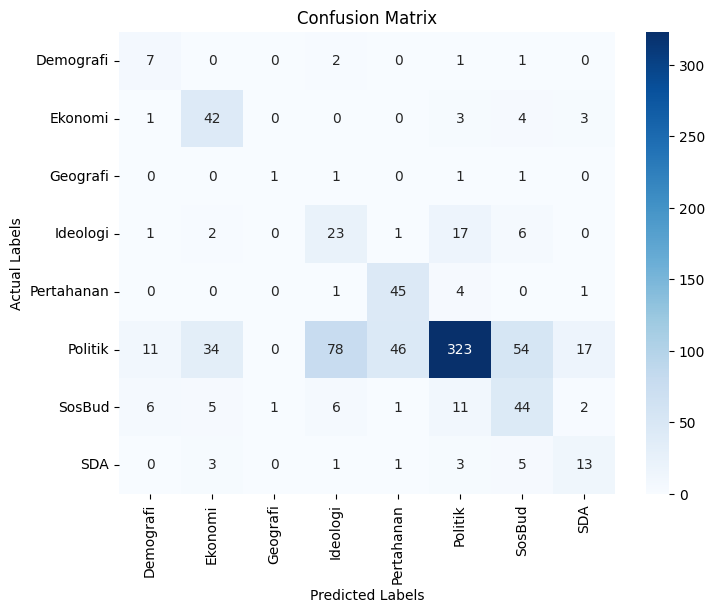

In [ ]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'cb_model' is your trained CatBoost model and 'val_df_split' contains the validation data
# Get the class names from the CatBoost model
class_names = cb_model.classes_.tolist()
print(class_names)
class_names = ['Demografi', 'Ekonomi', 'Geografi', 'Ideologi', 'Pertahanan', 'Politik', 'SosBud', 'SDA']
# class_names = ['Other', 'Politik']

# Assuming 'val_pool' is the validation data pool and 'predictions' are made using the model
# predictions = cb_model.predict(val_pool)  # This line should be run in your environment

# Calculate balanced accuracy
balanced_acc = balanced_accuracy_score(val_df_split['label'], final_pred)
print("Balanced Accuracy:", balanced_acc)

# Generate the confusion matrix
cm = confusion_matrix(val_df_split['label'], final_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Geo
report = classification_report(val_df_split['label'], final_pred, target_names=class_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

   Demografi       0.27      0.64      0.38        11
     Ekonomi       0.49      0.79      0.60        53
    Geografi       0.50      0.25      0.33         4
    Ideologi       0.21      0.46      0.28        50
  Pertahanan       0.48      0.88      0.62        51
     Politik       0.89      0.57      0.70       563
      SosBud       0.38      0.58      0.46        76
         SDA       0.36      0.50      0.42        26

    accuracy                           0.60       834
   macro avg       0.45      0.58      0.47       834
weighted avg       0.73      0.60      0.63       834



In [ ]:
x = train_kw_df[kw_df["keyword"].to_list() + ["text"]]
y = train_kw_df["label"]

In [ ]:
x.head()

   pendidikan rendah  kelompok etnis  masyarakat lintas etnis  kaum difabel  \
0                  0               0                        0             0   
1                  0               0                        0             0   
2                  1               0                        0             0   
3                  0               0                        0             0   
4                  0               0                        0             0   

   bugis  generasi emas  low educated  menengah bawah  kalangan atas  \
0      0              0             0               0              0   
1      0              0             0               0              0   
2      0              0             0               0              0   
3      0              0             0               0              0   
4      0              0             0               0              0   

   populasi jawa  ...  manyargubi  politik merdeka  futrijasun  vidaanasution  \
0          

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []
for train_index, test_index in tqdm(skf.split(x, y)):
  train_df_split_kf, val_df_split_kf = train_kw_df.iloc[train_index], train_kw_df.iloc[test_index]

  one_vs_all = list()
  labels = ["label", "label_demo", "label_aman", "label_eko"]
  for label in labels:
    train_pool, val_pool = get_pool(train_df_split_kf, val_df_split_kf, label)
    weight = count_weight(train_df_split_kf, label)

    cb_model = CatBoostClassifier(
      loss_function='MultiClass',
      eval_metric='TotalF1',
      task_type="GPU",
      devices="0",
      verbose=0,
      random_state=42,
      class_weights = weight
    )

    cb_model.fit(
        train_pool,
        eval_set=val_pool
    )

    if label == "label":
      predictions = cb_model.predict(val_pool)
      one_vs_all.append(predictions)
    else:
      # Predict class probabilities
      probabilities = cb_model.predict(val_pool, prediction_type='Probability')

      class_names = cb_model.classes_  # This will get the class names

      result = []
      for instance_probs in probabilities:
          max_index = np.argmax(instance_probs)  # Index of the highest probability
          max_class = class_names[max_index]
          max_proba = instance_probs[max_index]
          result.append({"class": max_class, "proba": max_proba})

      # one_vs_all[label] = result
      one_vs_all.append(result)

  final_pred = []
  for pred, pred_demo, pred_aman, pred_eko in zip(*one_vs_all):
    if pred[0] == 'Base':
      final_pred.append(pred[0])
    # elif pred_geo['class'] == 'Geografi' and pred_geo['proba'] > 0.7:
    #   final_pred.append('Geografi')
    elif pred_demo['class'] == 'Demografi' and pred_demo['proba'] > 0.5:
      final_pred.append('Demografi')
    # elif pred_sda['class'] == 'Sumber Daya Alam' and pred_sda['proba'] > 0.50:
    #   final_pred.append('Sumber Daya Alam')
    # elif pred_ide['class'] == 'Ideologi' and pred_ide['proba'] > 0.65:
    #   final_pred.append('Ideologi')
    elif pred_aman['class'] == 'Pertahanan dan Keamanan' and pred_aman['proba'] > 0.5:
      final_pred.append('Pertahanan dan Keamanan')
    elif pred_eko['class'] == 'Ekonomi' and pred_eko['proba'] > 0.6:
      final_pred.append('Ekonomi')
    # elif pred_sos['class'] == 'Sosial Budaya' and pred_sos['proba'] > 0.58:
    #   final_pred.append('Sosial Budaya')
    else:
      final_pred.append(pred[0])

  balanced_acc = balanced_accuracy_score(val_df_split_kf['label'], final_pred)
  scores.append(balanced_acc)

print(scores)
print(np.array(scores).mean())

[0.5918437599500325, 0.5527669830797013, 0.4779100988974652, 0.5285556932035071, 0.5198607049043624]
0.5341874480070137


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []
for train_index, test_index in tqdm(skf.split(x, y)):
  train_df_split_kf, val_df_split_kf = train_kw_df.iloc[train_index], train_kw_df.iloc[test_index]

  one_vs_all = list()
  labels = ["label", "label_demo", "label_aman", "label_eko"]
  for label in labels:
    train_pool, val_pool = get_pool(train_df_split_kf, val_df_split_kf, label)
    weight = count_weight(train_df_split_kf, label)

    cb_model = CatBoostClassifier(
      loss_function='MultiClass',
      eval_metric='TotalF1',
      task_type="GPU",
      devices="0",
      verbose=0,
      random_state=42,
      class_weights = weight
    )

    cb_model.fit(
        train_pool,
        # eval_set=val_pool
    )

    if label == "label":
      predictions = cb_model.predict(val_pool)
      one_vs_all.append(predictions)
    else:
      # Predict class probabilities
      probabilities = cb_model.predict(val_pool, prediction_type='Probability')

      class_names = cb_model.classes_  # This will get the class names

      result = []
      for instance_probs in probabilities:
          max_index = np.argmax(instance_probs)  # Index of the highest probability
          max_class = class_names[max_index]
          max_proba = instance_probs[max_index]
          result.append({"class": max_class, "proba": max_proba})

      # one_vs_all[label] = result
      one_vs_all.append(result)

  final_pred = []
  for pred, pred_demo, pred_aman, pred_eko in zip(*one_vs_all):
    if pred[0] == 'Base':
      final_pred.append(pred[0])
    # elif pred_geo['class'] == 'Geografi' and pred_geo['proba'] > 0.7:
    #   final_pred.append('Geografi')
    elif pred_demo['class'] == 'Demografi' and pred_demo['proba'] > 0.5:
      final_pred.append('Demografi')
    # elif pred_sda['class'] == 'Sumber Daya Alam' and pred_sda['proba'] > 0.50:
    #   final_pred.append('Sumber Daya Alam')
    # elif pred_ide['class'] == 'Ideologi' and pred_ide['proba'] > 0.65:
    #   final_pred.append('Ideologi')
    elif pred_aman['class'] == 'Pertahanan dan Keamanan' and pred_aman['proba'] > 0.5:
      final_pred.append('Pertahanan dan Keamanan')
    elif pred_eko['class'] == 'Ekonomi' and pred_eko['proba'] > 0.6:
      final_pred.append('Ekonomi')
    # elif pred_sos['class'] == 'Sosial Budaya' and pred_sos['proba'] > 0.58:
    #   final_pred.append('Sosial Budaya')
    else:
      final_pred.append(pred[0])

  balanced_acc = balanced_accuracy_score(val_df_split_kf['label'], final_pred)
  scores.append(balanced_acc)

print(scores)
print(np.array(scores).mean())

[0.5618628204852973, 0.5136077531813485, 0.49469502371845553, 0.47460306956744414, 0.5371060601599582]
0.5163749454225007


In [ ]:
model_1 = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type="GPU",
    devices="0",
    verbose=0,
    random_state=42,
    class_weights=class_weights_dict,
    text_features=['text']
)


cv_method = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
cv_results_model_1 = cross_val_score(estimator=model_1, X=train_kw_df.drop("label", axis=1), y=train_kw_df["label"], cv=cv_method,
                                     verbose=100, scoring='balanced_accuracy')

print("Model 1 - Balanced Accuracy scores: ")
print(cv_results_model_1)
print("Mean: ")
print(cv_results_model_1.mean().round(3))